# Lab 08: Optimization Methods

**Optimization** seeks the values of decision variables that minimize (or maximize) an
objective function:
$$\min_{x} f(x) \quad \text{(or } \max_x f(x) = \min_x -f(x)\text{)}$$

Engineering optimization problems appear everywhere:
- Minimize structural weight subject to strength constraints
- Find the cylinder dimensions that use the least material for a given volume
- Tune model parameters to best fit experimental data

### Key Terminology

| Term | Meaning |
|------|---------|
| **Global minimum** | Smallest $f$ over the entire domain |
| **Local minimum** | Smaller than all nearby points, but not necessarily globally smallest |
| **Unimodal** | Only one minimum in the search interval |
| **Gradient** $\nabla f$ | Vector of partial derivatives; points in the direction of steepest ascent |
| **Unconstrained** | No restrictions on $x$ |
| **Constrained** | $x$ must satisfy equality/inequality constraints |

## Learning Objectives

By the end of this session, you will be able to:
- Distinguish local and global minima and identify unimodal functions
- Implement and analyze the **Golden-Section Search** for 1-D minimization
- Implement **Parabolic Interpolation** and compare with Golden-Section
- Implement **Steepest Descent** (gradient descent) with backtracking line search
- Use `scipy.optimize.minimize_scalar` and `minimize` for production optimization
- Apply optimization methods to engineering design problems

## Session Outline

| # | Topic |  
|---|-------| 
| 1 | Introduction: Local vs. Global, 1-D vs. Multi-D |  
| 2 | Golden-Section Search |  
| 3 | Parabolic Interpolation |  
| 4 | Steepest Descent (Gradient Descent) |  
| 5 | `scipy.optimize` and Engineering Applications |   
| 6 | (Optional) Constrained Optimization |  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, minimize

<!-- 비가오면 땅이 젖는다. 
비가 내림 (충분조건)=> 땅이 젖음 (필요조건)
비내리는 것은 땅이 젖기에 충분함

비가 왔다면, 땅은 반드시 젖어야 해. 
땅이 젖는 것이 필요해. 

비는 땅을 적시기에 충분하고, 젖은 땅은 비가왔는 증거로 필요해. 
 -->

---
## 1. Introduction: Local vs. Global Minima

A **necessary condition** for a local minimum at $x^*$ (for smooth $f$):
$$f'(x^*) = 0 \quad \text{(1-D)}$$
$$\nabla f(x^*) = \mathbf{0} \quad \text{(multi-D)}$$

A **sufficient condition** for a local **minimum** (1-D):
$$f'(x^*) = 0 \quad \text{and} \quad f''(x^*) > 0$$

Most numerical methods find **local** minima.  
Finding the **global** minimum is much harder (requires global search strategies).

### Running Example
Throughout this lab we use:
$$f(x) = \frac{x^2}{10} - 2\sin(x)$$

In [ ]:
# Running example: f(x) = x²/10 - 2sin(x)
f1d = lambda x: x**2 / 10.0 - 2.0 * np.sin(x)

x = np.linspace(-2, 8, 500)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, f1d(x), 'b-', lw=2, label='$f(x) = x^2/10 - 2\\sin(x)$')
ax.axhline(0, color='k', lw=0.5)

# Mark local and global minima analytically (approximate)
from scipy.optimize import minimize_scalar as ms
res_global = ms(f1d, bounds=(0, 4), method='bounded')
res_local  = ms(f1d, bounds=(5, 8), method='bounded')

ax.plot(res_global.x, res_global.fun, 'r*', ms=18, zorder=5,
        label=f'Global min: $x^*={res_global.x:.4f}$, $f={res_global.fun:.4f}$')
ax.plot(res_local.x,  res_local.fun,  'gs', ms=14, zorder=5,
        label=f'Local min:  $x^*={res_local.x:.4f}$, $f={res_local.fun:.4f}$')

ax.set(xlabel='$x$', ylabel='$f(x)$',
       title='$f(x) = x^2/10 - 2\\sin(x)$: Local vs. Global Minimum')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('Note: numerical methods started in [0, 4] find the global minimum.')
print('      numerical methods started in [5, 8] find only a local minimum.')

---
## 2. Golden-Section Search

### 2.1 Idea

Analogous to **bisection** for root-finding, **Golden-Section Search** shrinks a bracket
$[x_l, x_u]$ known to contain a minimum of a **unimodal** function.

At each step, two interior points $x_1 > x_2$ are placed symmetrically:
$$d = (\varphi - 1)(x_u - x_l), \qquad x_1 = x_l + d, \quad x_2 = x_u - d$$
where $\varphi = \dfrac{1+\sqrt{5}}{2} \approx 1.618$ is the **golden ratio**.

### 2.2 Update Rule (Minimization)

Compare $f(x_1)$ and $f(x_2)$:

| Condition | Keep interval | Rationale |
|-----------|--------------|----------|
| $f(x_1) < f(x_2)$ | $[x_2,\, x_u]$ | Minimum is to the right of $x_2$ |
| $f(x_1) \geq f(x_2)$ | $[x_l,\, x_1]$ | Minimum is to the left of $x_1$ |

**Key property:** After the update, one of the old interior points becomes the new interior point,
so only **one new function evaluation** is needed per iteration.

### 2.3 Convergence

Each iteration reduces the interval by factor $(\varphi - 1) \approx 0.618$ — **linear convergence**.  
Approximate relative error: $\varepsilon_a = (2 - \varphi) \left|\dfrac{\Delta x}{x_{\rm opt}}\right|$
where $\Delta x = x_u - x_l$.

Golden ratio phi  = 1.61803399
phi - 1           = 0.61803399  (fraction of interval for interior points)
2 - phi           = 0.38196601  (reduction factor per step)


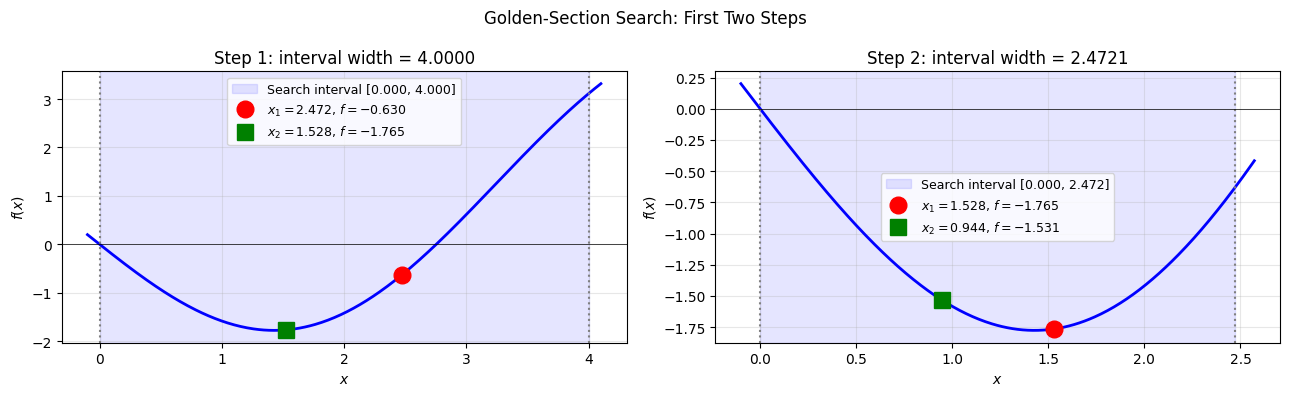


Step 1: x2=1.5279, x1=2.4721
  f(x1)=-0.6300, f(x2)=-1.7647
  f(x1) >= f(x2)?  True
  -> minimum is to the left of x1; new bracket = [xl, x1] = [0.0000, 2.4721]


In [4]:
# Visualize two steps of Golden-Section Search
phi = (1.0 + np.sqrt(5)) / 2.0
print(f'Golden ratio phi  = {phi:.8f}')
print(f'phi - 1           = {phi - 1:.8f}  (fraction of interval for interior points)')
print(f'2 - phi           = {2 - phi:.8f}  (reduction factor per step)')

xl0, xu0 = 0.0, 4.0
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for step, ax in enumerate(axes):
    if step == 0:
        xl, xu = xl0, xu0
    else:
        xl, xu = xl0, x1_prev   # f(x1) >= f(x2) case: keep [xl, x1]

    d  = (phi - 1) * (xu - xl)
    x1 = xl + d
    x2 = xu - d

    x_plot = np.linspace(xl - 0.1, xu + 0.1, 400)
    ax.plot(x_plot, f1d(x_plot), 'b-', lw=2)
    ax.axvline(xl, color='gray', ls=':', lw=1.5)
    ax.axvline(xu, color='gray', ls=':', lw=1.5)
    ax.axvspan(xl, xu, alpha=0.10, color='blue', label=f'Search interval [{xl:.3f}, {xu:.3f}]')
    ax.plot(x1, f1d(x1), 'ro', ms=12, zorder=5, label=f'$x_1={x1:.3f}$, $f={f1d(x1):.3f}$')
    ax.plot(x2, f1d(x2), 'gs', ms=12, zorder=5, label=f'$x_2={x2:.3f}$, $f={f1d(x2):.3f}$')
    ax.axhline(0, color='k', lw=0.5)
    ax.set(xlabel='$x$', ylabel='$f(x)$',
           title=f'Step {step+1}: interval width = {xu-xl:.4f}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    if step == 0:
        x1_prev = x1   # for step 2 (f(x1) >= f(x2) → keep [xl, x1])

plt.suptitle('Golden-Section Search: First Two Steps', fontsize=12)
plt.tight_layout(); plt.show()

# First step decision
d  = (phi - 1) * (xu0 - xl0)
x1 = xl0 + d;  x2 = xu0 - d
print(f'\nStep 1: x2={x2:.4f}, x1={x1:.4f}')
print(f'  f(x1)={f1d(x1):.4f}, f(x2)={f1d(x2):.4f}')
print(f'  f(x1) >= f(x2)?  {f1d(x1) >= f1d(x2)}')
print(f'  -> minimum is to the left of x1; new bracket = [xl, x1] = [{xl0:.4f}, {x1:.4f}]')

In [6]:
def goldmin(f, xl, xu, es=1e-7, maxit=100):
    """
    Find the minimum of a unimodal f on [xl, xu] using Golden-Section Search.

    Parameters
    ----------
    f       : callable — unimodal objective function
    xl, xu  : float   — initial bracket
    es      : float   — stopping criterion (approx. relative error)
    maxit   : int     — maximum iterations

    Returns
    -------
    xopt    : float  — minimizer estimate
    fopt    : float  — f(xopt)
    ea      : float  — final approximate relative error
    n_iter  : int    — iterations performed
    history : list of (iter, xopt, f(xopt), ea, interval_width)
    """
    phi = (1.0 + np.sqrt(5)) / 2.0

    d  = (phi - 1) * (xu - xl)
    x1 = xl + d;  f1 = f(x1)
    x2 = xu - d;  f2 = f(x2)

    history = []
    xopt = x1 if f1 < f2 else x2

    for i in range(maxit):
        xint = xu - xl   # current interval width

        if f1 < f2:
            # minimum is to the right of x2: new bracket = [x2, xu]
            xopt = x1
            # --- COMPLETE: update bracket and interior points ---
            xl = x2          # shift left bound to old x2
            x2 = x1          # old x1 becomes new left interior point
            f2 = f1
            x1 =              xl + (phi - 1) * (xu - xl)#   — new right interior point
            f1 = f(x1)
            # --- COMPLETE ---
        else:
            # minimum is to the left of x1: new bracket = [xl, x1]
            xopt = x2
            # --- COMPLETE: update bracket and interior points ---
            xu = x1          # shift right bound to old x1
            x1 = x2          # old x2 becomes new right interior point
            f1 = f2
            x2 =              xu - (phi - 1) * (xu - xl) #  — new left interior point
            f2 = f(x2)
            # --- COMPLETE ---

        ea = (2.0 - phi) * abs(xint / xopt) if xopt != 0 else (2.0 - phi) * abs(xint)
        history.append((i + 1, xopt, f(xopt), ea, xu - xl))

        if ea < es:
            break

    return xopt, f(xopt), ea, i + 1, history

<!-- SOLUTION
# f1 < f2 branch:
x1 = xl + (phi - 1) * (xu - xl)

# else branch:
x2 = xu - (phi - 1) * (xu - xl)
-->

In [7]:
# Test goldmin on the running example
x_true = 1.4275517797083348   # known global minimum (from scipy)

xopt, fopt, ea, n_iter, history = goldmin(f1d, xl=0.0, xu=4.0, es=1e-9, maxit=100)

print(f'Minimum found : x* = {xopt:.10f}')
print(f'f(x*)         : {fopt:.10f}')
print(f'True minimum  : {x_true:.10f}')
print(f'|error|       : {abs(xopt - x_true):.3e}')
print(f'Iterations    : {n_iter}')

# Iteration table
print(f'\n{"Iter":>5}  {"xopt":>14}  {"f(xopt)":>14}  {"ea":>12}  {"interval":>10}')
print('-' * 62)
for row in history[::3]:   # print every 3rd row to keep table short
    print(f'{row[0]:>5}  {row[1]:>14.8f}  {row[2]:>14.8f}  {row[3]:>12.6e}  {row[4]:>10.6f}')

Minimum found : x* = 1.4275517674
f(x*)         : -1.7757256531
True minimum  : 1.4275517797
|error|       : 1.229e-08
Iterations    : 45

 Iter            xopt         f(xopt)            ea    interval
--------------------------------------------------------------
    1      1.52786405     -1.76472025  1.000000e+00    2.472136
    4      1.52786405     -1.76472025  2.360680e-01    0.583592
    7      1.44271910     -1.77547480  5.901699e-02    0.137767
   10      1.42261911     -1.77569914  1.412887e-02    0.032522
   13      1.42736407     -1.77572561  3.324285e-03    0.007678
   16      1.42736407     -1.77572561  7.847573e-04    0.001812
   19      1.42752750     -1.77572565  1.852349e-04    0.000428
   22      1.42756608     -1.77572565  4.372684e-05    0.000101
   25      1.42755134     -1.77572565  1.032261e-05    0.000024
   28      1.42755134     -1.77572565  2.436838e-06    0.000006
   31      1.42755216     -1.77572565  5.752591e-07    0.000001
   34      1.42755185     -1.7

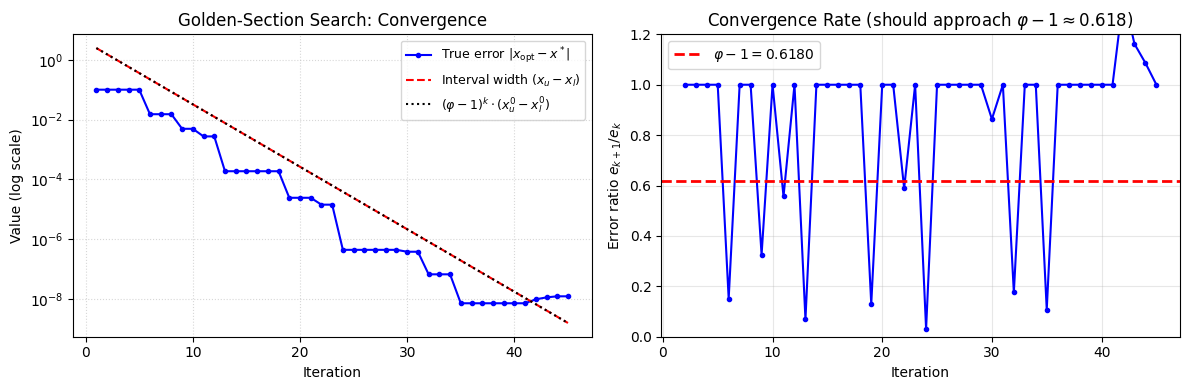

Linear convergence: each step reduces interval by factor phi-1 = 0.618034
Iterations needed for interval < 1e-08: ~42


In [8]:
# Convergence analysis
iters     = [row[0] for row in history]
true_err  = [abs(row[1] - x_true) for row in history]
intervals = [row[4] for row in history]

phi = (1 + np.sqrt(5)) / 2
theo_interval = [(4.0 - 0.0) * (phi - 1)**k for k in iters]  # (phi-1)^k * initial width

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(iters, true_err, 'b.-', ms=6, label='True error $|x_{\\rm opt} - x^*|$')
ax.semilogy(iters, intervals, 'r--', lw=1.5, label='Interval width $(x_u - x_l)$')
ax.semilogy(iters, theo_interval, 'k:', lw=1.5, label='$(\\varphi-1)^k \\cdot (x_u^0 - x_l^0)$')
ax.set(xlabel='Iteration', ylabel='Value (log scale)',
       title='Golden-Section Search: Convergence')
ax.legend(fontsize=9); ax.grid(True, which='both', ls=':', alpha=0.5)

ax = axes[1]
# Show linear convergence: error ratio per step
ratios = [true_err[k+1] / true_err[k] for k in range(len(true_err)-1) if true_err[k] > 1e-14]
ax.plot(iters[1:len(ratios)+1], ratios, 'b.-', ms=6)
ax.axhline(phi - 1, color='r', ls='--', lw=2, label=f'$\\varphi-1 = {phi-1:.4f}$')
ax.set(xlabel='Iteration', ylabel='Error ratio $e_{k+1}/e_k$',
       title='Convergence Rate (should approach $\\varphi-1 \\approx 0.618$)',
       ylim=[0, 1.2])
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Linear convergence: each step reduces interval by factor phi-1 = {phi-1:.6f}')
eps = 1e-8
n_needed = np.ceil(np.log(eps / 4.0) / np.log(phi - 1))
print(f'Iterations needed for interval < {eps}: ~{n_needed:.0f}')

**Exercise:** Apply `goldmin` to find the **local** minimum of $f(x) = x^2/10 - 2\sin(x)$
in the interval $[5, 8]$. How does its value compare to the global minimum found above?

In [ ]:
# --- YOUR CODE HERE ---
# Apply goldmin to find the local minimum in [5, 8]


---
## 3. Parabolic Interpolation

### 3.1 Algorithm

Instead of using only the bracket endpoints, **Parabolic Interpolation** fits a
**quadratic polynomial** through three points $(x_1, f_1)$, $(x_2, f_2)$, $(x_3, f_3)$
and jumps directly to the parabola's vertex:

$$x_4 = x_2 - \frac{1}{2}\cdot
\frac{(x_2 - x_1)^2[f_2 - f_3] - (x_2 - x_3)^2[f_2 - f_1]}
{(x_2 - x_1)[f_2 - f_3] - (x_2 - x_3)[f_2 - f_1]}$$

If $f$ is well-approximated by a parabola near the minimum, this can be much faster than
Golden-Section Search.

### 3.2 Update

After computing $x_4$, replace the worst of the three current points and repeat.
The iteration terminates when $|x_4^{\rm new} - x_4^{\rm old}|$ is small enough.

### 3.3 Convergence

Near a smooth minimum, convergence is **superlinear** (order $\approx 1.32$).
However, the method can fail if the three points are nearly collinear (denominator $\approx 0$).

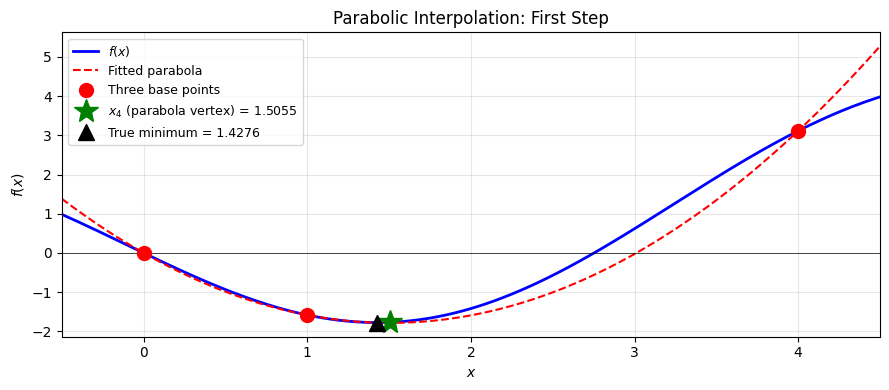

Three base points: x1=0.0, x2=1.0, x3=4.0
Parabola vertex x4 = 1.505535
True minimum x*    = 1.427552
Golden-section first step would give midpoint-like estimate


In [9]:
# Visualize one parabolic interpolation step
x1_p, x2_p, x3_p = 0.0, 1.0, 4.0
y1_p, y2_p, y3_p = f1d(x1_p), f1d(x2_p), f1d(x3_p)

num = (x2_p-x1_p)**2*(y2_p-y3_p) - (x2_p-x3_p)**2*(y2_p-y1_p)
den = (x2_p-x1_p)*(y2_p-y3_p)    - (x2_p-x3_p)*(y2_p-y1_p)
x4_p = x2_p - 0.5 * num / den

# Fit parabola through the three points for visualization
coeffs = np.polyfit([x1_p, x2_p, x3_p], [y1_p, y2_p, y3_p], 2)
xp_plot = np.linspace(-0.5, 4.5, 300)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xp_plot, f1d(xp_plot), 'b-', lw=2, label='$f(x)$')
ax.plot(xp_plot, np.polyval(coeffs, xp_plot), 'r--', lw=1.5, label='Fitted parabola')
ax.plot([x1_p, x2_p, x3_p], [y1_p, y2_p, y3_p], 'ro', ms=10, zorder=5,
        label='Three base points')
ax.plot(x4_p, f1d(x4_p), 'g*', ms=18, zorder=5,
        label=f'$x_4$ (parabola vertex) = {x4_p:.4f}')
ax.plot(x_true, f1d(x_true), 'k^', ms=12, zorder=5,
        label=f'True minimum = {x_true:.4f}')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='$x$', ylabel='$f(x)$', title='Parabolic Interpolation: First Step',
       xlim=[-0.5, 4.5])
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Three base points: x1={x1_p}, x2={x2_p}, x3={x3_p}')
print(f'Parabola vertex x4 = {x4_p:.6f}')
print(f'True minimum x*    = {x_true:.6f}')
print(f'Golden-section first step would give midpoint-like estimate')

In [10]:
def parabolic(f, x1, x2, x3, es=1e-7, maxit=50):
    """
    Minimize f using Parabolic Interpolation.

    Requires three initial points x1 < x2 < x3 with f(x2) < f(x1) and f(x2) < f(x3).

    Parameters
    ----------
    f       : callable
    x1, x2, x3 : float — initial three points  (x1 < x2 < x3)
    es      : float   — stopping criterion
    maxit   : int

    Returns
    -------
    x4, f(x4), ea, n_iter, history
    """
    history = []
    x4_old = x2

    for i in range(maxit):
        y1, y2, y3 = f(x1), f(x2), f(x3)

        num = (x2 - x1)**2 * (y2 - y3) - (x2 - x3)**2 * (y2 - y1)
        den = (x2 - x1) * (y2 - y3)    - (x2 - x3) * (y2 - y1)

        if abs(den) < 1e-30:
            break   # denominator near zero — cannot proceed

        # --- COMPLETE: parabolic interpolation formula ---
        x4 =                               x2 - 0.5 * num / den
        # --- COMPLETE ---

        ea = abs((x4 - x4_old) / x4) if x4 != 0 else abs(x4 - x4_old)
        history.append((i + 1, x4, f(x4), ea))

        if ea < es:
            break

        # Update: replace the worst of the three points
        pts = sorted([(f(p), p) for p in [x1, x2, x3, x4]], key=lambda t: t[0])
        x1, x2, x3 = sorted([pts[0][1], pts[1][1], pts[2][1]])

        x4_old = x4

    return x4, f(x4), ea, i + 1, history

<!-- SOLUTION
x4 = x2 - 0.5 * num / den
-->

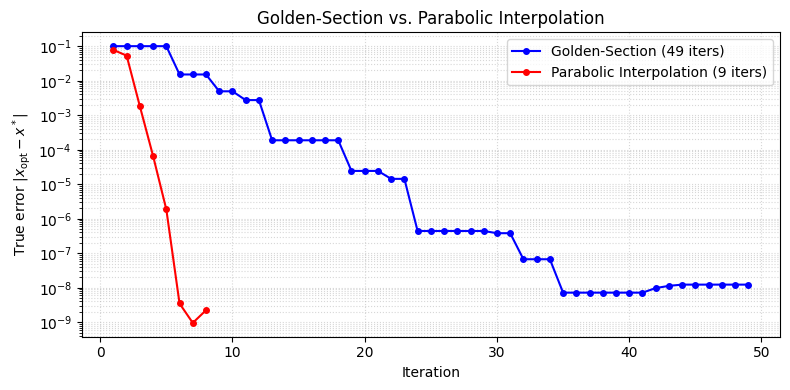

Golden-Section:          49 iterations,  final |error| = 1.229e-08
Parabolic Interpolation:  9 iterations,  final |error| = 2.222e-09

Note: Parabolic converges faster when f is smooth near the minimum.

Use: curvature information of a function


In [12]:
# Compare Golden-Section vs Parabolic Interpolation
xopt_gs, fopt_gs, _, n_gs, hist_gs = goldmin(f1d, 0.0, 4.0, es=1e-10, maxit=100)
xopt_pi, fopt_pi, _, n_pi, hist_pi = parabolic(f1d, 0.0, 1.0, 4.0, es=1e-10, maxit=50)

err_gs = [abs(row[1] - x_true) for row in hist_gs if abs(row[1] - x_true) > 0]
err_pi = [abs(row[1] - x_true) for row in hist_pi if abs(row[1] - x_true) > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(err_gs)+1), err_gs, 'b.-', ms=8,
            label=f'Golden-Section ({n_gs} iters)')
ax.semilogy(range(1, len(err_pi)+1), err_pi, 'r.-', ms=8,
            label=f'Parabolic Interpolation ({n_pi} iters)')
ax.set(xlabel='Iteration', ylabel='True error $|x_{\\rm opt} - x^*|$',
       title='Golden-Section vs. Parabolic Interpolation')
ax.legend(); ax.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout(); plt.show()

print(f'Golden-Section:         {n_gs:3d} iterations,  final |error| = {abs(xopt_gs - x_true):.3e}')
print(f'Parabolic Interpolation:{n_pi:3d} iterations,  final |error| = {abs(xopt_pi - x_true):.3e}')
print('\nNote: Parabolic converges faster when f is smooth near the minimum.')
print('\nUse: curvature information of a function')

---
## 4. Steepest Descent (Gradient Descent)

### 4.1 From 1-D to Multi-D

For a function $f(\mathbf{x})$ with $\mathbf{x} \in \mathbb{R}^n$, the **gradient**
$\nabla f$ points in the direction of **steepest ascent**.
Moving in the **negative gradient direction** decreases $f$ most rapidly.

### 4.2 Algorithm

Given $\mathbf{x}^{(0)}$, for $k = 0, 1, 2, \ldots$:
1. Compute gradient: $\mathbf{g}^{(k)} = \nabla f(\mathbf{x}^{(k)})$
2. Choose step size: $\alpha^{(k)}$ (line search)
3. Update: $\mathbf{x}^{(k+1)} = \mathbf{x}^{(k)} - \alpha^{(k)} \mathbf{g}^{(k)}$
4. Stop if $\|\nabla f(\mathbf{x}^{(k)})\| < \varepsilon$ or $\|\mathbf{x}^{(k+1)} - \mathbf{x}^{(k)}\| < \delta$

### 4.3 Choosing the Step Size $\alpha$ (Line Search)

- **Too large:** $f$ increases (overshoots minimum)
- **Too small:** convergence is slow
- **Backtracking (Armijo) rule:** start with $\alpha = 1$; while $f(\mathbf{x} - \alpha\mathbf{g}) \geq f(\mathbf{x})$, set $\alpha \leftarrow c\,\alpha$ (with $c < 1$)

### 4.4 Convergence

Steepest descent has **linear convergence**. For strongly convex $f$:
$$\|\mathbf{x}^{(k)} - \mathbf{x}^*\| \leq \left(\frac{\kappa - 1}{\kappa + 1}\right)^k \|\mathbf{x}^{(0)} - \mathbf{x}^*\|$$
where $\kappa = \lambda_{\max}/\lambda_{\min}$ is the **condition number** of the Hessian.
High condition number → slow, zigzagging convergence.

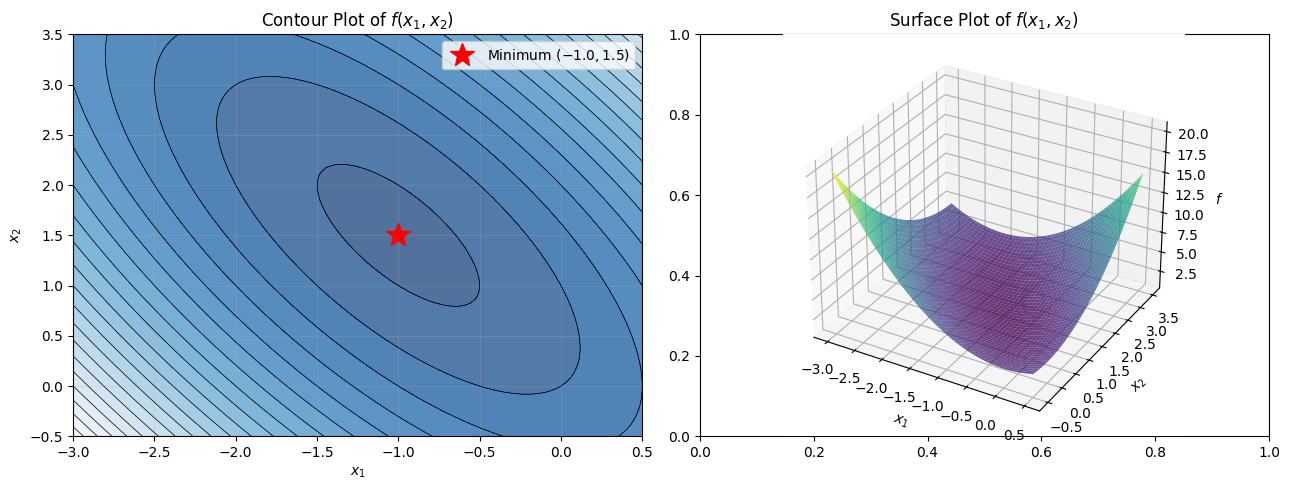

Analytical minimum at x = [-1.   1.5],  f = 0.750000
Gradient at minimum: [0. 0.]


In [13]:
# Running 2D example: f(x, y) = 2 + x - y + 2x² + 2xy + y²
# Analytical minimum: ∂f/∂x = 1+4x+2y=0, ∂f/∂y = -1+2x+2y=0 → x=-1, y=3/2

def f2d(x):
    return 2.0 + x[0] - x[1] + 2*x[0]**2 + 2*x[0]*x[1] + x[1]**2

def grad_f2d(x):
    return np.array([1.0 + 4*x[0] + 2*x[1],
                    -1.0 + 2*x[0] + 2*x[1]])

x2_true = np.array([-1.0, 1.5])   # exact minimum

# Visualize
x1_arr = np.linspace(-3.0, 0.5, 100)
x2_arr = np.linspace(-0.5, 3.5, 100)
XX, YY = np.meshgrid(x1_arr, x2_arr)
ZZ = 2 + XX - YY + 2*XX**2 + 2*XX*YY + YY**2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.contourf(XX, YY, ZZ, levels=20, cmap='Blues_r', alpha=0.7)
cs = ax.contour(XX, YY, ZZ, levels=20, colors='k', linewidths=0.5)
ax.plot(*x2_true, 'r*', ms=18, zorder=5, label=f'Minimum $({x2_true[0]}, {x2_true[1]})$')
ax.set(xlabel='$x_1$', ylabel='$x_2$', title='Contour Plot of $f(x_1, x_2)$')
ax.legend(); ax.grid(True, alpha=0.2)

ax = axes[1]
from mpl_toolkits.mplot3d import Axes3D   # noqa
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.plot_surface(XX, YY, ZZ, cmap='viridis', alpha=0.8, linewidth=0)
ax.set(xlabel='$x_1$', ylabel='$x_2$', zlabel='$f$',
       title='Surface Plot of $f(x_1, x_2)$')

plt.tight_layout(); plt.show()

print(f'Analytical minimum at x = {x2_true},  f = {f2d(x2_true):.6f}')
print(f'Gradient at minimum: {np.round(grad_f2d(x2_true), 10)}')

In [ ]:
# Visualize the gradient as arrows on the contour plot
x1_g = np.linspace(-3.0, 0.5, 8)
x2_g = np.linspace(-0.5, 3.5, 8)
XG, YG = np.meshgrid(x1_g, x2_g)

# Compute gradients at each grid point
UG = np.zeros_like(XG)
VG = np.zeros_like(YG)
for i in range(XG.shape[0]):
    for j in range(XG.shape[1]):
        g = grad_f2d(np.array([XG[i,j], YG[i,j]]))
        UG[i,j] = g[0]
        VG[i,j] = g[1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.contour(XX, YY, ZZ, levels=15, colors='gray', linewidths=0.7)
ax.quiver(XG, YG, UG, VG, color='blue', alpha=0.7, scale=80,
          label='$\\nabla f$ (steepest ascent)')
ax.quiver(XG, YG, -UG, -VG, color='red', alpha=0.5, scale=80,
          label='$-\\nabla f$ (steepest descent)')
ax.plot(*x2_true, 'k*', ms=18, zorder=5, label='Minimum')
ax.set(xlabel='$x_1$', ylabel='$x_2$',
       title='Gradient Direction on Contour Plot')
ax.legend(fontsize=10); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

<!-- x =                                     x - alpha * g  # — steepest descent step -->

In [ ]:
def backtrack_linesearch(f, x, grad, c=0.5, alpha0=1.0, max_ls=50):
    """
    Backtracking line search: find alpha so that f(x - alpha*grad) < f(x).

    Starts from alpha0 and multiplies by c until descent condition is satisfied.
    """
    alpha = alpha0
    fx = f(x)
    for _ in range(max_ls):
        if f(x - alpha * grad) < fx:
            break
        alpha *= c
    return alpha


def steepest_descent(f, grad_f, x0, tol=1e-6, maxit=1000, record=True):
    """
    Minimize f using steepest descent with backtracking line search.

    Parameters
    ----------
    f      : callable — objective function, accepts 1-D array
    grad_f : callable — gradient function, returns 1-D array
    x0     : array-like — initial guess
    tol    : float    — stopping criterion: ||grad f|| < tol
    maxit  : int      — maximum iterations
    record : bool     — record iteration history

    Returns
    -------
    x       : array  — minimizer estimate
    f(x)    : float
    n_iter  : int
    history : list of (iter, x.copy(), f(x), ||grad||, alpha)
    """
    x = np.array(x0, dtype=float)
    history = []

    for i in range(maxit):
        g = grad_f(x)
        grad_norm = np.linalg.norm(g)

        if record:
            history.append((i, x.copy(), f(x), grad_norm, None))

        if grad_norm < tol:
            break

        # --- COMPLETE: gradient descent update ---
        alpha = backtrack_linesearch(f, x, g)   # backtracking line search
        x =                                    # x - alpha * g  # — steepest descent step
        # --- COMPLETE ---

        if record and history:
            history[-1] = (history[-1][0], history[-1][1],
                           history[-1][2], history[-1][3], alpha)

    return x, f(x), i + 1, history

<!-- SOLUTION
x = x - alpha * g
-->

Starting point    : [-2.  3.]
Minimizer found   : [-1.00000001  1.50000001]
True minimum      : [-1.   1.5]
f(minimizer)      : 0.7500000000
f(true min)       : 0.7500000000
|error|           : 2.107e-08
Iterations        : 200


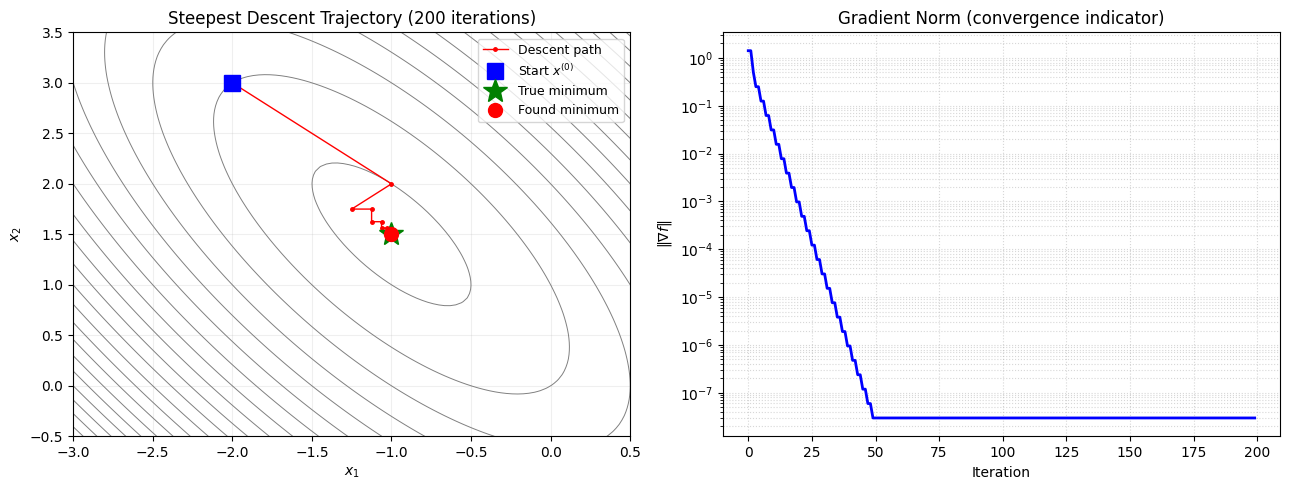

In [16]:
# Test steepest descent on the 2D example
x0 = np.array([-2.0, 3.0])
xopt2d, fopt2d, n_sd, hist_sd = steepest_descent(f2d, grad_f2d, x0, tol=1e-8, maxit=200)

print(f'Starting point    : {x0}')
print(f'Minimizer found   : {np.round(xopt2d, 8)}')
print(f'True minimum      : {x2_true}')
print(f'f(minimizer)      : {fopt2d:.10f}')
print(f'f(true min)       : {f2d(x2_true):.10f}')
print(f'|error|           : {np.linalg.norm(xopt2d - x2_true):.3e}')
print(f'Iterations        : {n_sd}')

# Trajectory on contour plot
traj = np.array([row[1] for row in hist_sd])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.contour(XX, YY, ZZ, levels=20, colors='gray', linewidths=0.7)
ax.plot(traj[:, 0], traj[:, 1], 'r.-', ms=5, lw=1, label='Descent path')
ax.plot(x0[0], x0[1], 'bs', ms=12, zorder=5, label='Start $x^{(0)}$')
ax.plot(*x2_true, 'g*', ms=18, zorder=5, label='True minimum')
ax.plot(xopt2d[0], xopt2d[1], 'ro', ms=10, zorder=5, label='Found minimum')
ax.set(xlabel='$x_1$', ylabel='$x_2$',
       title=f'Steepest Descent Trajectory ({n_sd} iterations)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

ax = axes[1]
grad_norms = [row[3] for row in hist_sd]
ax.semilogy(range(len(grad_norms)), grad_norms, 'b-', lw=2)
ax.set(xlabel='Iteration', ylabel='$\\|\\nabla f\\|$',
       title='Gradient Norm (convergence indicator)')
ax.grid(True, which='both', ls=':', alpha=0.5)

plt.tight_layout(); plt.show()

Hessian eigenvalues: [0.8769 9.1231]
Condition number kappa = 10.4039
Theoretical rate (kappa-1)/(kappa+1) = 0.8246
Iterations: 50


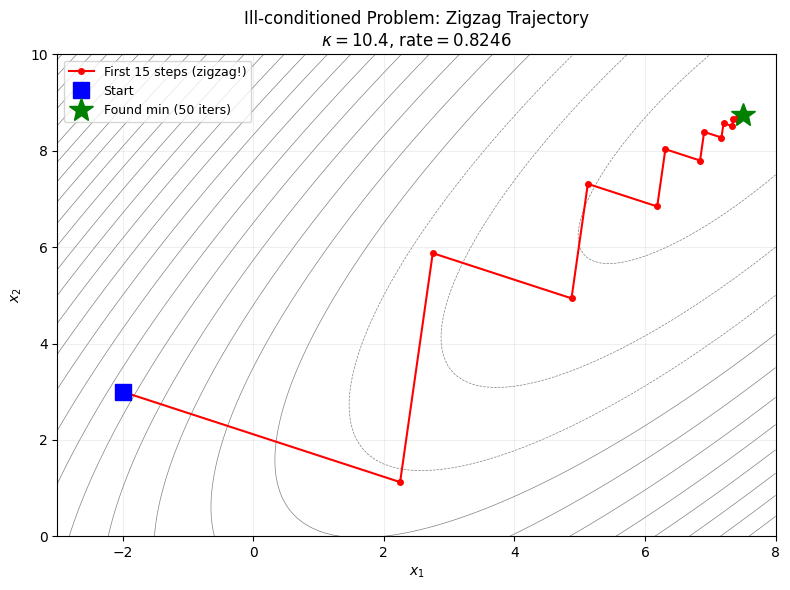


Observation: high condition number -> slow, zigzagging steepest descent.
Better methods (Newton, BFGS) are needed for ill-conditioned problems.


In [17]:
# Ill-conditioned example: f = 3x² - 10x - 4xy + 2y² - 5y + 8
# Minimum: ∂f/∂x = 6x - 10 - 4y = 0, ∂f/∂y = -4x + 4y - 5 = 0
# → x = 25/4, y = 25/4 + 5/4 = 30/4 = 7.5

def f_ill(x):
    return 3*x[0]**2 - 10*x[0] - 4*x[0]*x[1] + 2*x[1]**2 - 5*x[1] + 8

def grad_ill(x):
    return np.array([6*x[0] - 10 - 4*x[1],
                    -4*x[0] + 4*x[1] - 5])

x0_ill = np.array([-2.0, 3.0])
xopt_ill, fopt_ill, n_ill, hist_ill = steepest_descent(f_ill, grad_ill, x0_ill,
                                                        tol=1e-6, maxit=500)

# Hessian of f_ill: [[6, -4], [-4, 4]]  → eigenvalues
H_ill = np.array([[6.0, -4.0], [-4.0, 4.0]])
eigvals_ill = np.linalg.eigvalsh(H_ill)
kappa_ill = eigvals_ill[-1] / eigvals_ill[0]
rate_ill = (kappa_ill - 1) / (kappa_ill + 1)

print(f'Hessian eigenvalues: {np.round(eigvals_ill, 4)}')
print(f'Condition number kappa = {kappa_ill:.4f}')
print(f'Theoretical rate (kappa-1)/(kappa+1) = {rate_ill:.4f}')
print(f'Iterations: {n_ill}')

# Plot zigzag trajectory
traj_ill = np.array([row[1] for row in hist_ill])
x1i = np.linspace(-3, 8, 100)
x2i = np.linspace(0, 10, 100)
XI, YI = np.meshgrid(x1i, x2i)
ZI = 3*XI**2 - 10*XI - 4*XI*YI + 2*YI**2 - 5*YI + 8

fig, ax = plt.subplots(figsize=(8, 6))
ax.contour(XI, YI, ZI, levels=30, colors='gray', linewidths=0.5)
ax.plot(traj_ill[:15, 0], traj_ill[:15, 1], 'r.-', ms=8, lw=1.5,
        label='First 15 steps (zigzag!)')
ax.plot(x0_ill[0], x0_ill[1], 'bs', ms=12, zorder=5, label='Start')
ax.plot(xopt_ill[0], xopt_ill[1], 'g*', ms=18, zorder=5,
        label=f'Found min ({n_ill} iters)')
ax.set(xlabel='$x_1$', ylabel='$x_2$',
       title=f'Ill-conditioned Problem: Zigzag Trajectory\n$\\kappa={kappa_ill:.1f}$, rate$={rate_ill:.4f}$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

print('\nObservation: high condition number -> slow, zigzagging steepest descent.')
print('Better methods (Newton, BFGS) are needed for ill-conditioned problems.')

**Exercise:** Try steepest descent with a **fixed** step size (e.g., $\alpha = 0.01, 0.1, 0.5$)
instead of backtracking. Observe how the choice of $\alpha$ affects convergence.

Hint: replace `backtrack_linesearch(...)` with a constant `alpha`.

In [ ]:
# --- YOUR CODE HERE ---
# Try fixed step sizes alpha = 0.01, 0.1, 0.5 on f2d
# Plot convergence curves for each


---
## 5. `scipy.optimize` and Engineering Applications

### 5.1 1-D: `minimize_scalar`

| Method | Algorithm | Notes |
|--------|-----------|-------|
| `'brent'` | Brent's method (parabolic + golden) | Default; robust and fast |
| `'golden'` | Pure golden-section | Guaranteed, slower |
| `'bounded'` | Brent within $[a, b]$ | Use when bounds are known |

In [18]:
print('=== minimize_scalar on f(x) = x²/10 - 2sin(x) ===')
for method in ['brent', 'golden', 'bounded']:
    kwargs = {'bounds': (0, 4)} if method == 'bounded' else {'bracket': (0, 4)}
    res = minimize_scalar(f1d, method=method, **kwargs)
    print(f'{method:8s}: x* = {res.x:.10f},  f* = {res.fun:.10f},  evals = {res.nfev}')

print(f'\nOur goldmin:   x* = {xopt:.10f},  iters = {n_iter}')

=== minimize_scalar on f(x) = x²/10 - 2sin(x) ===
brent   : x* = 1.4275517813,  f* = -1.7757256531,  evals = 13
golden  : x* = 1.4275517796,  f* = -1.7757256531,  evals = 46
bounded : x* = 1.4275517993,  f* = -1.7757256531,  evals = 8

Our goldmin:   x* = 1.4275517674,  iters = 45


### 5.2 Multi-D: `minimize`

| Method | Type | Gradient? | Notes |
|--------|------|-----------|-------|
| `'Nelder-Mead'` | Direct search | No | Robust but slow; good for noisy $f$ |
| `'BFGS'` | Quasi-Newton | Yes (or finite diff.) | Fast; approximates Hessian |
| `'L-BFGS-B'` | Limited-memory BFGS | Yes | Best for large-scale + box constraints |
| `'CG'` | Conjugate gradient | Yes | Memory-efficient |
| `'SLSQP'` | Sequential QP | Yes | Equality + inequality constraints |

In [19]:
print('=== minimize on f2d(x) = 2+x1-x2+2x1²+2x1x2+x2² ===')
print(f'{"Method":<14}  {"x1*":>10}  {"x2*":>10}  {"f*":>12}  {"Evals":>6}  {"Iters":>6}')
print('-' * 66)

for method in ['Nelder-Mead', 'BFGS', 'L-BFGS-B', 'CG']:
    try:
        res = minimize(f2d, x0=[-2.0, 3.0], method=method,
                       jac=grad_f2d if method != 'Nelder-Mead' else None,
                       tol=1e-10)
        print(f'{method:<14}  {res.x[0]:>10.6f}  {res.x[1]:>10.6f}  '
              f'{res.fun:>12.8f}  {res.nfev:>6}  {res.nit:>6}')
    except Exception as e:
        print(f'{method:<14}  ERROR: {e}')

print(f'{"Our SD":<14}  {xopt2d[0]:>10.6f}  {xopt2d[1]:>10.6f}  '
      f'{fopt2d:>12.8f}  {"N/A":>6}  {n_sd:>6}')
print(f'\nTrue minimum: x1* = {x2_true[0]}, x2* = {x2_true[1]}, f* = {f2d(x2_true):.8f}')

=== minimize on f2d(x) = 2+x1-x2+2x1²+2x1x2+x2² ===
Method                 x1*         x2*            f*   Evals   Iters
------------------------------------------------------------------
Nelder-Mead      -1.000000    1.500000    0.75000000     159      79
BFGS             -1.000000    1.500000    0.75000000       6       4
L-BFGS-B         -1.000000    1.500000    0.75000000       6       5
CG               -1.000000    1.500000    0.75000000      19      11
Our SD           -1.000000    1.500000    0.75000000     N/A     200

True minimum: x1* = -1.0, x2* = 1.5, f* = 0.75000000


### 5.3 Engineering Application: Optimal Cylinder Design

Design a cylindrical can with volume $V_0 = 1000$ cm³.  
**Objective:** minimize the total surface area $A$ (= material cost):
$$A(r, h) = 2\pi r h + 2\pi r^2 \quad \text{(lateral + top + bottom)}$$

**Constraint:** $V = \pi r^2 h = V_0 \Rightarrow h = \dfrac{V_0}{\pi r^2}$

Substituting, we get a 1-D unconstrained problem:
$$A(r) = \frac{2V_0}{r} + 2\pi r^2$$

The analytical solution is $r^* = \left(\dfrac{V_0}{2\pi}\right)^{1/3}$,  $h^* = 2r^*$ (height = diameter).

=== Optimal Cylinder Design (V = 1000.0 cm³) ===
Analytical: r* = 5.419261 cm,  h* = 10.838521 cm
            h*/r* = 2.000000  (should be 2.0 — height = diameter)
            A* = 553.581045 cm²


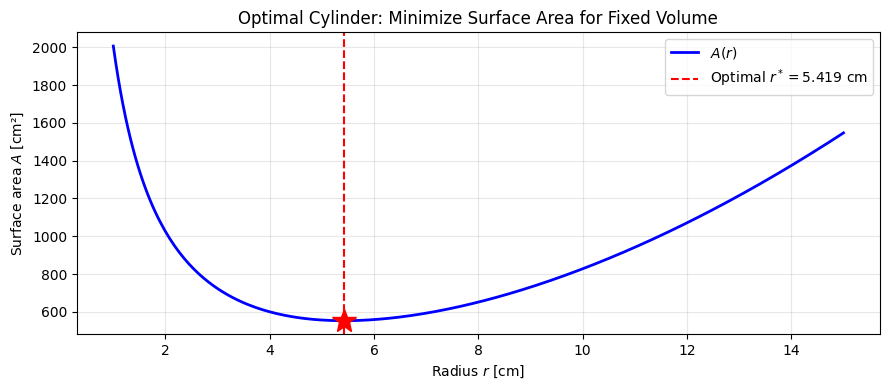


=== Numerical Results ===
Golden-Section:  r* = 5.41926068 cm  (45 iters)
scipy brent:     r* = 5.41926045 cm  (11 evals)
Analytical:      r* = 5.41926070 cm


In [20]:
V0 = 1000.0  # cm³

def area(r):
    """Surface area of cylinder with volume V0 as a function of radius r."""
    h = V0 / (np.pi * r**2)
    return 2 * np.pi * r * h + 2 * np.pi * r**2

# Analytical optimum
r_star = (V0 / (2 * np.pi))**(1/3)
h_star = V0 / (np.pi * r_star**2)
A_star = area(r_star)

print(f'=== Optimal Cylinder Design (V = {V0} cm³) ===')
print(f'Analytical: r* = {r_star:.6f} cm,  h* = {h_star:.6f} cm')
print(f'            h*/r* = {h_star/r_star:.6f}  (should be 2.0 — height = diameter)')
print(f'            A* = {A_star:.6f} cm²')

# Plot objective function
r_arr = np.linspace(1, 15, 300)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(r_arr, area(r_arr), 'b-', lw=2, label='$A(r)$')
ax.axvline(r_star, color='r', ls='--', lw=1.5, label=f'Optimal $r^*={r_star:.3f}$ cm')
ax.plot(r_star, A_star, 'r*', ms=18, zorder=5)
ax.set(xlabel='Radius $r$ [cm]', ylabel='Surface area $A$ [cm²]',
       title='Optimal Cylinder: Minimize Surface Area for Fixed Volume')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Numerical solutions
print('\n=== Numerical Results ===')
xopt_gs_cy, _, _, n_gs_cy, _ = goldmin(area, 1.0, 15.0, es=1e-9)
res_brent = minimize_scalar(area, bounds=(1, 15), method='bounded')

print(f'Golden-Section:  r* = {xopt_gs_cy:.8f} cm  ({n_gs_cy} iters)')
print(f'scipy brent:     r* = {res_brent.x:.8f} cm  ({res_brent.nfev} evals)')
print(f'Analytical:      r* = {r_star:.8f} cm')

### 5.4 (Optional) Constrained Optimization

Many engineering problems have explicit constraints:
$$\min_{\mathbf{x}} f(\mathbf{x}) \quad \text{subject to} \quad g_i(\mathbf{x}) \leq 0, \quad h_j(\mathbf{x}) = 0$$

`scipy.optimize.minimize` with `method='SLSQP'` handles both types.

In [21]:
# Constrained cylinder: minimize A(r, h) subject to pi*r²*h = V0
# (treating r and h as two independent variables)

def area_rh(x):
    r, h = x
    return 2 * np.pi * r * h + 2 * np.pi * r**2

constraints = [
    {'type': 'eq', 'fun': lambda x: np.pi * x[0]**2 * x[1] - V0}
]
bounds_rh = [(0.1, 20), (0.1, 100)]  # r in [0.1, 20], h in [0.1, 100]

res_slsqp = minimize(area_rh, x0=[5.0, 10.0], method='SLSQP',
                     constraints=constraints, bounds=bounds_rh,
                     options={'ftol': 1e-10})

r_slsqp, h_slsqp = res_slsqp.x
print('=== Constrained Optimization (SLSQP) ===')
print(f'r* = {r_slsqp:.8f} cm,  h* = {h_slsqp:.8f} cm')
print(f'h*/r* = {h_slsqp/r_slsqp:.6f}  (should be 2.0)')
print(f'A* = {area_rh(res_slsqp.x):.6f} cm²  (should be {A_star:.6f})')
print(f'Volume check: pi*r²*h = {np.pi * r_slsqp**2 * h_slsqp:.6f}  (should be {V0})')
print(f'\nAnalytical: r* = {r_star:.8f}, h* = {h_star:.8f}, A* = {A_star:.6f}')

=== Constrained Optimization (SLSQP) ===
r* = 5.41926078 cm,  h* = 10.83852111 cm
h*/r* = 2.000000  (should be 2.0)
A* = 553.581045 cm²  (should be 553.581045)
Volume check: pi*r²*h = 1000.000000  (should be 1000.0)

Analytical: r* = 5.41926070, h* = 10.83852140, A* = 553.581045


**Exercise:** Extend the cylinder problem. Suppose the material cost per cm² for the
top/bottom discs is **twice** as expensive as the lateral surface:
$$\text{Cost}(r, h) = 2\pi r h \cdot c_{\rm lateral} + 2\pi r^2 \cdot 2\,c_{\rm lateral}$$

Set $c_{\rm lateral} = 1$. Find the optimal $r^*$ and $h^*$ for $V_0 = 1000$ cm³.
Does the optimal ratio $h^*/r^*$ change?

=== Method 1: 1-D (constraint eliminated) ===
r* = 4.301270 cm,  h* = 17.205084 cm
h*/r* = 4.000001
Cost* = 697.468411

=== Method 2: 2-D constrained (SLSQP) ===
r* = 4.301270 cm,  h* = 17.205078 cm,  h*/r* = 3.999999

=== Analytical ===
r* = (V0 / (4 pi))^(1/3) = 4.301270 cm
h* = 17.205080 cm,  h*/r* = 4.000000

=== Comparison ===
Case                            r*          h*     h*/r*
-------------------------------------------------------
Equal cost                  5.4193     10.8385    2.0000
Top/bottom 2x cost          4.3013     17.2051    4.0000


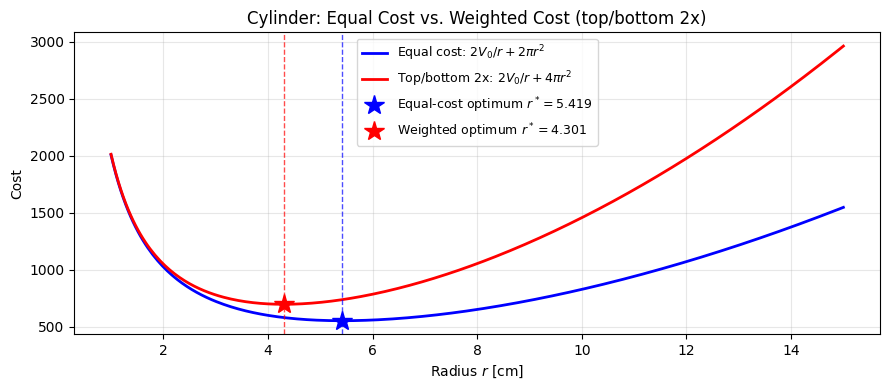


Interpretation:
  When top/bottom discs are twice as expensive, the optimum shifts to a
  SMALLER radius and a TALLER can: the ratio h*/r* doubles from 2 to 4.
  Intuition: shrink the expensive circular ends; compensate with height.


In [22]:
# Weighted cost: top/bottom discs twice as expensive as lateral surface
V0    = 1000.0   # cm^3
c_lat = 1.0      # cost per cm^2 for the lateral surface

# --- Method 1: 1-D minimization (substitute h = V0 / (pi r^2)) ---
# Cost(r, h) = 2 pi r h * c_lat + 2 pi r^2 * 2 c_lat
#            = 2 V0 / r * c_lat + 4 pi r^2 * c_lat   (after substitution)
def cost_1d(r):
    return 2 * V0 * c_lat / r + 4 * np.pi * r**2 * c_lat

res_1d = minimize_scalar(cost_1d, bounds=(0.1, 20), method='bounded')
r_opt  = res_1d.x
h_opt  = V0 / (np.pi * r_opt**2)

print('=== Method 1: 1-D (constraint eliminated) ===')
print(f'r* = {r_opt:.6f} cm,  h* = {h_opt:.6f} cm')
print(f'h*/r* = {h_opt/r_opt:.6f}')
print(f'Cost* = {cost_1d(r_opt):.6f}')

# --- Method 2: 2-D constrained optimization with SLSQP ---
def cost_rh(x):
    r, h = x
    return 2*np.pi*r*h*c_lat + 2*np.pi*r**2 * 2*c_lat

constraints = [{'type': 'eq', 'fun': lambda x: np.pi * x[0]**2 * x[1] - V0}]
res_2d = minimize(cost_rh, x0=[5.0, 10.0], method='SLSQP',
                  constraints=constraints, bounds=[(0.1, 20), (0.1, 100)],
                  options={'ftol': 1e-10})
r2, h2 = res_2d.x
print('\n=== Method 2: 2-D constrained (SLSQP) ===')
print(f'r* = {r2:.6f} cm,  h* = {h2:.6f} cm,  h*/r* = {h2/r2:.6f}')

# --- Analytical check ---
# d/dr [2 V0 / r + 4 pi r^2] = -2 V0 / r^2 + 8 pi r = 0  =>  r^3 = V0 / (4 pi)
r_ana = (V0 / (4 * np.pi))**(1/3)
h_ana = V0 / (np.pi * r_ana**2)
print('\n=== Analytical ===')
print(f'r* = (V0 / (4 pi))^(1/3) = {r_ana:.6f} cm')
print(f'h* = {h_ana:.6f} cm,  h*/r* = {h_ana/r_ana:.6f}')

# --- Compare with equal-cost baseline ---
print('\n=== Comparison ===')
print(f'{"Case":<22}  {"r*":>10}  {"h*":>10}  {"h*/r*":>8}')
print('-' * 55)
print(f'{"Equal cost":<22}  {r_star:>10.4f}  {h_star:>10.4f}  {h_star/r_star:>8.4f}')
print(f'{"Top/bottom 2x cost":<22}  {r_opt:>10.4f}  {h_opt:>10.4f}  {h_opt/r_opt:>8.4f}')

# --- Plot cost curves ---
r_arr = np.linspace(1, 15, 300)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(r_arr, 2*V0/r_arr + 2*np.pi*r_arr**2, 'b-', lw=2,
        label='Equal cost: $2V_0/r + 2\\pi r^2$')
ax.plot(r_arr, cost_1d(r_arr), 'r-', lw=2,
        label='Top/bottom 2x: $2V_0/r + 4\\pi r^2$')
ax.axvline(r_star, color='b', ls='--', lw=1, alpha=0.7)
ax.axvline(r_opt,  color='r', ls='--', lw=1, alpha=0.7)
ax.plot(r_star, 2*V0/r_star + 2*np.pi*r_star**2, 'b*', ms=15, zorder=5,
        label=f'Equal-cost optimum $r^*={r_star:.3f}$')
ax.plot(r_opt, cost_1d(r_opt), 'r*', ms=15, zorder=5,
        label=f'Weighted optimum $r^*={r_opt:.3f}$')
ax.set(xlabel='Radius $r$ [cm]', ylabel='Cost',
       title='Cylinder: Equal Cost vs. Weighted Cost (top/bottom 2x)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('\nInterpretation:')
print('  When top/bottom discs are twice as expensive, the optimum shifts to a')
print('  SMALLER radius and a TALLER can: the ratio h*/r* doubles from 2 to 4.')
print('  Intuition: shrink the expensive circular ends; compensate with height.')

---
## Summary

### Methods Overview

| Method | Dim | Gradient? | Convergence | Notes |
|--------|-----|-----------|-------------|-------|
| **Golden-Section** | 1-D | No | Linear (rate $\varphi-1 \approx 0.618$) | Requires unimodal bracket; robust |
| **Parabolic Interpolation** | 1-D | No | Superlinear ($\approx 1.32$) | Fast for smooth $f$; may fail |
| **Steepest Descent** | $n$-D | Yes $\nabla f$ | Linear (rate $(\kappa-1)/(\kappa+1)$) | Zigzags for ill-conditioned $f$ |
| **`scipy` brent** | 1-D | No | Superlinear | Hybrid gold+parabolic; recommended |
| **`scipy` BFGS** | $n$-D | Yes (or FD) | Superlinear | Best general-purpose unconstrained |
| **`scipy` SLSQP** | $n$-D | Yes (or FD) | Superlinear | Handles eq. + ineq. constraints |

### Key Formulas

| Method | Core Formula |
|--------|-------------|
| **Golden ratio** | $\varphi = (1+\sqrt{5})/2 \approx 1.618$ |
| **Interior points** | $d = (\varphi-1)(x_u-x_l)$, $\;x_1 = x_l+d$, $\;x_2 = x_u-d$ |
| **Parabolic vertex** | $x_4 = x_2 - \frac{1}{2}\cdot\dfrac{(x_2-x_1)^2(f_2-f_3) - (x_2-x_3)^2(f_2-f_1)}{(x_2-x_1)(f_2-f_3) - (x_2-x_3)(f_2-f_1)}$ |
| **Gradient descent** | $\mathbf{x}^{(k+1)} = \mathbf{x}^{(k)} - \alpha^{(k)} \nabla f(\mathbf{x}^{(k)})$ |
| **Convergence rate** | $(\kappa-1)/(\kappa+1)$ where $\kappa = \lambda_{\max}/\lambda_{\min}$ (Hessian) |

### Decision Guide

```
1-D problem?
  YES → Use scipy.optimize.minimize_scalar (method='brent' or 'bounded')
        For teaching/understanding: goldmin or parabolic

Multi-D problem?
  Do you have constraints?
    YES → scipy.optimize.minimize(method='SLSQP')  — with bounds/constraints
    NO  → scipy.optimize.minimize(method='BFGS') or 'L-BFGS-B'
  Is f noisy or non-smooth?
    YES → method='Nelder-Mead'  (derivative-free)
    NO  → method='BFGS'  (fastest for smooth f)
```

### Engineering Applications

| Application | Objective | Method |
|-------------|-----------|--------|
| Cylinder can design | Minimize surface area | `goldmin` / `minimize_scalar` |
| Structural weight | Minimize mass s.t. stress ≤ limit | `minimize` + SLSQP |
| Curve fitting | Minimize $\sum(y_i - f(x_i;\theta))^2$ | `minimize` + BFGS |
| Control tuning | Minimize tracking error | `minimize` + L-BFGS-B |